In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer

In [2]:
data=pd.read_csv("campus_sustainability_dataset.csv")

In [3]:
data.isnull().sum()

Clothing_Spend_per_Month       0
Food_Type                      0
Housing_Type                   0
Energy_Usage_kWh_per_Month     0
Water_Usage_Liters_per_Day     0
Transportation_Mode            0
Consumption_Spend_per_Month    0
Recycling_Habits               0
Carbon_Emissions_kgCO2         0
dtype: int64

In [4]:
data.head()

,Clothing_Spend_per_Month,Food_Type,Housing_Type,Energy_Usage_kWh_per_Month,Water_Usage_Liters_per_Day,Transportation_Mode,Consumption_Spend_per_Month,Recycling_Habits,Carbon_Emissions_kgCO2
0,1360,Non-Vegetarian,Apartment,478,277,Public_Transport,4136,Always,369.630
1,4272,Vegan,Own_House,69,151,Bicycle,4318,Always,158.860
2,3592,Vegetarian,Shared_House,322,124,Car,3782,Always,357.030
3,966,Non-Vegetarian,Shared_House,168,466,Public_Transport,8657,Never,247.745
4,4926,Vegetarian,Apartment,120,495,Walking,5920,Never,218.610


In [5]:
data["Food_Type"].unique()

array(['Non-Vegetarian', 'Vegan', 'Vegetarian', 'Mixed'], dtype=object)

In [6]:
data["Housing_Type"].unique()

array(['Apartment', 'Own_House', 'Shared_House', 'Dormitory'],
      dtype=object)

In [7]:
data["Resource_Usage"] = data["Energy_Usage_kWh_per_Month"] * data["Water_Usage_Liters_per_Day"]
data= pd.get_dummies(data, columns=["Housing_Type"],drop_first=True)

data["Energy_House"] = data["Energy_Usage_kWh_per_Month"] * data.filter(like="Housing_Type_").sum(axis=1)

data = pd.get_dummies(data, columns=["Transportation_Mode"],drop_first=True)

data["Transport_Impact"] = data["Consumption_Spend_per_Month"] * data.filter(like="Transportation_Mode_").sum(axis=1)

In [8]:
data=data.drop(columns=["Recycling_Habits","Food_Type","Transportation_Mode_Walking"])

In [9]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Clothing_Spend_per_Month              1000 non-null   int64  
 1   Energy_Usage_kWh_per_Month            1000 non-null   int64  
 2   Water_Usage_Liters_per_Day            1000 non-null   int64  
 3   Consumption_Spend_per_Month           1000 non-null   int64  
 4   Carbon_Emissions_kgCO2                1000 non-null   float64
 5   Resource_Usage                        1000 non-null   int64  
 6   Housing_Type_Dormitory                1000 non-null   bool   
 7   Housing_Type_Own_House                1000 non-null   bool   
 8   Housing_Type_Shared_House             1000 non-null   bool   
 9   Energy_House                          1000 non-null   int64  
 10  Transportation_Mode_Car               1000 non-null   bool   
 11  Transportation_Mod

<Axes: >

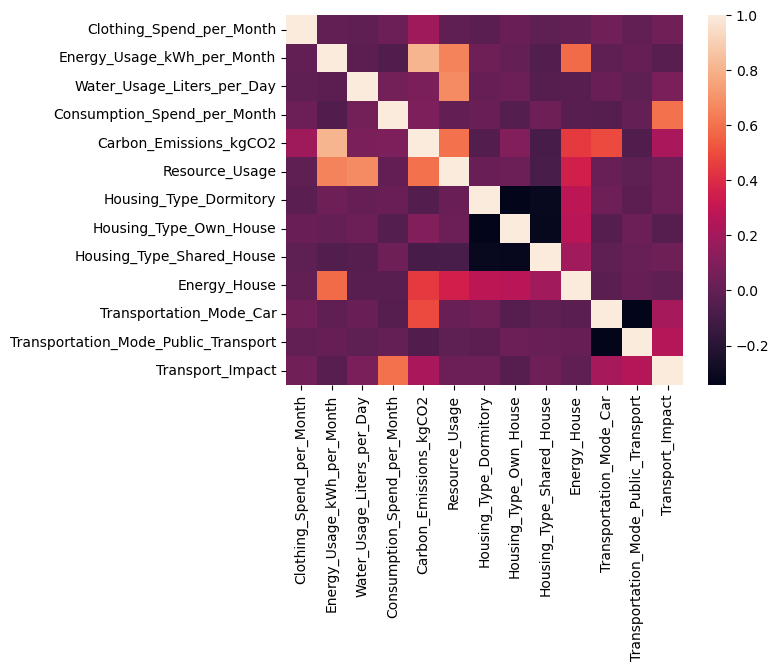

In [10]:
import seaborn as sns
sns.heatmap(data.corr(), annot=False)

In [11]:
data.columns

Index(['Clothing_Spend_per_Month', 'Energy_Usage_kWh_per_Month',
       'Water_Usage_Liters_per_Day', 'Consumption_Spend_per_Month',
       'Carbon_Emissions_kgCO2', 'Resource_Usage', 'Housing_Type_Dormitory',
       'Housing_Type_Own_House', 'Housing_Type_Shared_House', 'Energy_House',
       'Transportation_Mode_Car', 'Transportation_Mode_Public_Transport',
       'Transport_Impact'],
      dtype='object')

In [12]:
x=data.drop(columns=["Carbon_Emissions_kgCO2"])
y=data["Carbon_Emissions_kgCO2"]

In [13]:
x_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [14]:
numerical_columns=['Clothing_Spend_per_Month', 'Energy_Usage_kWh_per_Month',
       'Water_Usage_Liters_per_Day', 'Consumption_Spend_per_Month',
        'Resource_Usage', 'Housing_Type_Dormitory',
       'Housing_Type_Own_House', 'Housing_Type_Shared_House', 'Energy_House',
       'Transportation_Mode_Car', 'Transportation_Mode_Public_Transport',
       'Transport_Impact']

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
    ],
    remainder='drop'  
)

In [15]:
model=RandomForestRegressor()

In [16]:
model = Pipeline([
    ("preprocessor",preprocessor),
   ('model',model)
])

In [17]:
param_grid={
    "model__max_depth":[3,4,5,6,9],
    "model__n_estimators":[100,150,200],
    "model__min_samples_split": [3,4,5,10],
    "model__min_samples_leaf": [2,3,4,5],
    }

In [18]:
grid=GridSearchCV(model,param_grid,cv=5)

In [19]:
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [3, 4, ...], 'model__min_samples_leaf': [2, 3, ...], 'model__min_samples_split': [3, 4, ...], 'model__n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

In [20]:
y_pred=grid.predict(X_test)

In [21]:
accuracy=r2_score(y_test,y_pred)

In [22]:
print(accuracy)

0.9589556901214487


In [23]:
y_predict_tr=grid.predict(x_train)

In [24]:
accuracy_tra=r2_score(y_train,y_predict_tr)

In [25]:
print(accuracy_tra)

0.9891872393166872


In [26]:
import joblib

joblib.dump(grid, "carbon_model.pkl")

['carbon_model.pkl']